In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [3]:
df=pd.read_csv('height-weight.csv')

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


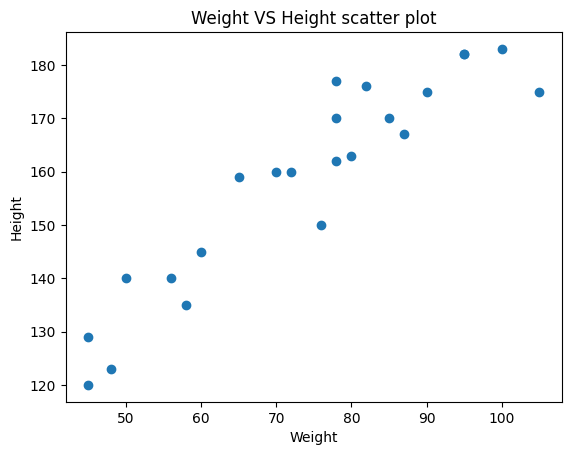

In [ ]:
##Scatter plot
plt.scatter(x='Weight',y='Height',data=df)
plt.xlabel("Weight")
plt.ylabel("Height") 
plt.title("Weight VS Height scatter plot")
plt.show()

In [6]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


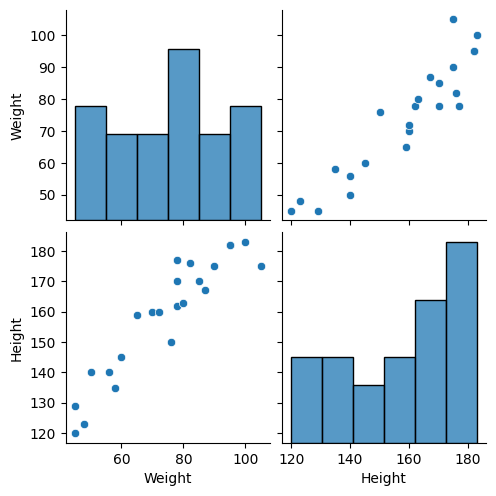

In [7]:
import seaborn as sns
sns.pairplot(df)

In [8]:
## Independent and dependent features
X=df[['Weight']] ## Make sure that the independent feature should be in DataFrame or 2 dimension array
y=df['Height'] ## it can be series or one D array



In [9]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [10]:
##Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [12]:
X_train.shape

(17, 1)

In [13]:
## Standardization
from sklearn.preprocessing import StandardScaler


In [14]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [16]:
## Apply Linear regression algorithm
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
print("Coefficient or slope",regression.coef_)

Coefficient or slope [17.2982057]


In [18]:
print("Intercept",regression.intercept_)

Intercept 156.47058823529412


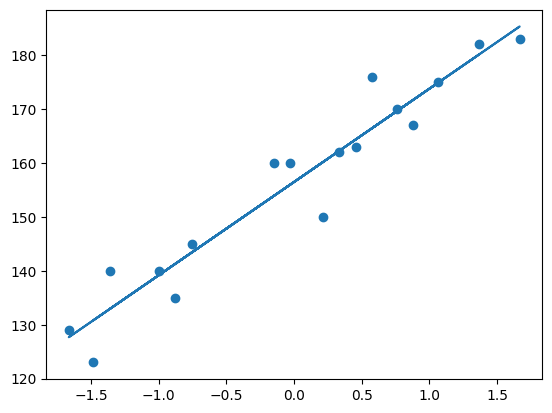

In [19]:
## Plot Training data plot best fit line 
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

PREDICTION OF TEST DATA

1. predicted height output= intercept + corf_(Weight)
2. y_pred_test=156.470 + 17.29(X_test)

In [20]:
##Prediction for test data
y_pred=regression.predict(X_test)

In [22]:
import math

In [24]:
## Performance matrix
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [25]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.7360826717981276


In [26]:
## Display adjusted r2
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [29]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.5 MB 4.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.5 MB 4.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.5 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 4.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 4.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 4.0 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 4.0 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 3.8 MB/s  0:00:02

   ------------------

In [30]:
## OLS linear reggression
import  statsmodels.api as sm

In [31]:
model=sm.OLS(y_train,X_train).fit()

In [32]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [33]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 10 Feb 2026   Prob (F-statistic):                       0.664
Time:                        17:46:19   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [34]:
## Prediction for new data
regression.predict(scaler.transform([[72]]))

c:\Users\amitk\OneDrive\Desktop\complete data analyst bootcamp\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])